# Skywork reward: обучение как с инструктивной моделью (TRL `RewardTrainer`)

**Модель:** `Skywork/Skywork-Reward-V2-Qwen3-1.7B` — загрузка в **bf16/fp16**, **без bitsandbytes** (никакого QLoRA, никакого `nvidia-nvjitlink`).

**Данные:** в репозитории `rep` лежат `dataset/splitted/train_ds.json` и `dataset/splitted/test_ds.json` — списки объектов с полями `instruction`, `model_answer`, `reference_answer`, **`agg_label`** (`"model"` \| `"reference"`), **`correct`** (0/1; из отфильтрованных примеров берётся подвыборка). Дальше они приводятся к парам `prompt` / `chosen` / `rejected` для TRL.

**HF Hub:** предупреждение про `HF_TOKEN` можно игнорировать или задать токен для лимитов. На обучение не влияет.


In [ ]:
from pathlib import Path

DATA_DIR = Path("..") / "dataset" / "splitted"
TRAIN_PATH = DATA_DIR / "train_ds.json"
TEST_PATH = DATA_DIR / "test_ds.json"

OUTPUT_DIR = Path(".") / "skywork_reward_trl_checkpoints"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

print("DATA_DIR:", DATA_DIR.resolve())
print("OUTPUT_DIR:", OUTPUT_DIR.resolve())
print("train exists:", TRAIN_PATH.is_file())
print("test  exists:", TEST_PATH.is_file())

DATA_DIR.resolve(), OUTPUT_DIR.resolve()

(PosixPath('/content/drive/MyDrive/nauchka'),
 PosixPath('/content/drive/MyDrive/nauchka/skywork_reward_trl_checkpoints'))

## Установка пакетов

**Без** `bitsandbytes` и **без** `nvidia-nvjitlink` — колёса с PyPI / PyTorch. После первой установки перезапусти kernel и снова выполни ячейки начиная с импортов.

Если в venv уже стоит подходящий `torch` с CUDA, закомментируй первую строку в ячейке ниже.


In [ ]:
# # PyTorch с CUDA (cu124 — стабильные колёса; при необходимости замените на cu121 с pytorch.org)
%pip install -q -U torch torchvision torchaudio --index-url https://download.pytorch.org/whl/cu124
# # TRL + трансформеры + PEFT (reward-модель грузится как SequenceClassification, без 4-bit)
%pip install -q -U "transformers>=4.44" "trl>=0.14" "peft>=0.11" accelerate datasets safetensors huggingface_hub
# torchao не ставить на torch<2.11 — ломает импорт transformers/peft (register_constant в _pytree).
%pip install -U "torchao>=0.16.0"

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.2/10.2 MB 112.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 697.4/697.4 kB 63.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 680.7/680.7 kB 65.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 527.0/527.0 kB 54.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 645.5/645.5 kB 60.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 47.6/47.6 MB 19.8 MB/s eta 0:00:00


In [4]:
import json
import os
import random

# Виртуалка: общий HF-кэш (если уже задан системой — не трогаем)
os.environ.setdefault("HF_HOME", "/shared/hf_cache")
# Иногда полезно явно задать и старые переменные кэша
os.environ.setdefault("TRANSFORMERS_CACHE", os.environ["HF_HOME"])
os.environ.setdefault("HF_HUB_CACHE", os.path.join(os.environ["HF_HOME"], "hub"))

import torch
from datasets import Dataset
from peft import LoraConfig
from trl import RewardConfig, RewardTrainer

os.environ.setdefault("TOKENIZERS_PARALLELISM", "false")

MODEL_ID = "Skywork/Skywork-Reward-V2-Qwen3-1.7B"
SEED = 42
random.seed(SEED)

print("HF_HOME:", os.environ.get("HF_HOME"))
print("HF_HUB_CACHE:", os.environ.get("HF_HUB_CACHE"))

_cuda = torch.cuda.is_available()
if not _cuda:
    raise RuntimeError("Нужна GPU с CUDA для этого ноутбука.")

_bf16 = torch.cuda.is_bf16_supported()
_fp16 = not _bf16
_dtype = torch.bfloat16 if _bf16 else torch.float16

# Как в старом ноутбуке: только dtype + trust_remote_code + device_map — без quantization_config
_model_init = {
    "dtype": _dtype,
    "trust_remote_code": True,
    "device_map": "auto",
    "num_labels": 1,
}

print("torch", torch.__version__, "cuda", torch.version.cuda, "bf16", _bf16)


torch 2.10.0+cu128 cuda 12.8 bf16 True


## Данные: `train_ds.json` / `test_ds.json`


In [5]:
def load_preference_json(path: Path) -> Dataset:
    """Читает JSON-массив: winner → chosen/rejected, prompt из instruction."""
    if not path.is_file():
        raise FileNotFoundError(f"Нет файла: {path.resolve()}")
    with path.open("r", encoding="utf-8") as f:
        raw = json.load(f)
    if not isinstance(raw, list):
        raise ValueError("Ожидается JSON-массив объектов.")

    rows = []
    for ex in raw:
        w = ex.get("agg_label")
        if w == "model":
            chosen, rejected = ex["model_answer"], ex["reference_answer"]
        elif w == "reference":
            chosen, rejected = ex["reference_answer"], ex["model_answer"]
        else:
            continue
        rows.append(
            {
                "prompt": ex["instruction"],
                "chosen": chosen,
                "rejected": rejected,
            }
        )
    if not rows:
        raise ValueError(f"Пусто или нет валидных пар в {path}")
    return Dataset.from_list(rows)


train_ds = load_preference_json(TRAIN_PATH)
eval_ds = load_preference_json(TEST_PATH)
print("train", len(train_ds), "eval", len(eval_ds))
train_ds[0]


train 700 eval 227


{'prompt': 'почему число 666 число дьявола',
 'chosen': 'Число **666** часто ассоциируется с дьяволом и злом из-за упоминания в **Библии**, а именно в **Откровении Иоанна Богослова (Апокалипсис)**, где оно символизирует «число зверя» – антихриста.  \n\n### **Библейское происхождение**  \nВ **Откровении 13:18** (Новый Завет) сказано:  \n> *«Здесь мудрость. Кто имеет ум, тот сочти *число зверя*, ибо это число человеческое; число его *шестьсот шестьдесят шесть*»*  \n\nЭтот отрывок интерпретируется как предупреждение о грядущем антихристе, которого символизирует зверь, а его число — **666**.  \n\n### **Значение числа 666**  \nСуществует несколько теорий о том, почему выбрано именно это число:  \n\n1. **Гематрия в Библии**  \n   - В древних языках (иврите, греческом) буквы имели числовое значение. Некоторые толкователи считают, что **666** может быть закодированным именем или титулом антихриста.  \n   - Наиболее известная версия: в еврейской гематрии **"Нерон Кесарь"** (император Нерон, гон

## Конфиг и LoRA (как в `train_reward_model_(2).ipynb`)


In [6]:
USE_LORA = True
from peft import TaskType

common_kw = dict(
    output_dir=str(OUTPUT_DIR),
    num_train_epochs=2,
    per_device_train_batch_size=4,
    per_device_eval_batch_size=4,
    gradient_accumulation_steps=8,
    learning_rate=1e-3 if USE_LORA else 1e-4,
    logging_steps=10,
    save_strategy="steps",
    save_steps=200,
    save_total_limit=2,
    bf16=_bf16,
    fp16=_fp16,
    gradient_checkpointing=True,
    center_rewards_coefficient=1e-2,
    model_init_kwargs=_model_init,
    max_length=2048,
    report_to="none",
    seed=SEED,
    dataloader_num_workers=0,
    dataloader_pin_memory=True,
)

if len(eval_ds) > 0:
    training_args = RewardConfig(
        **common_kw,
        eval_strategy="steps",
        eval_steps=100,
        load_best_model_at_end=True,
        metric_for_best_model="eval_loss",
        greater_is_better=False,
    )
else:
    training_args = RewardConfig(
        **common_kw,
        eval_strategy="no",
    )

peft_config = None
if USE_LORA:
    peft_config = LoraConfig(
        task_type=TaskType.SEQ_CLS,
        r=16,
        lora_alpha=32,
        lora_dropout=0.05,
        bias="none",
        target_modules=[
            "q_proj",
            "k_proj",
            "v_proj",
            "o_proj",
            "gate_proj",
            "up_proj",
            "down_proj",
        ],
        modules_to_save=["score"],
    )

training_args, peft_config


(RewardConfig(output_dir='/content/drive/MyDrive/nauchka/skywork_reward_trl_checkpoints', per_device_train_batch_size=4, num_train_epochs=2, max_steps=-1, learning_rate=0.001, lr_scheduler_type=<SchedulerType.LINEAR: 'linear'>, lr_scheduler_kwargs=None, warmup_steps=0, optim=<OptimizerNames.ADAMW_TORCH_FUSED: 'adamw_torch_fused'>, optim_args=None, weight_decay=0.0, adam_beta1=0.9, adam_beta2=0.999, adam_epsilon=1e-08, optim_target_modules=None, gradient_accumulation_steps=8, average_tokens_across_devices=True, max_grad_norm=1.0, label_smoothing_factor=0.0, bf16=True, fp16=False, bf16_full_eval=False, fp16_full_eval=False, tf32=None, gradient_checkpointing=True, gradient_checkpointing_kwargs=None, torch_compile=False, torch_compile_backend=None, torch_compile_mode=None, use_liger_kernel=False, liger_kernel_config=None, use_cache=False, neftune_noise_alpha=None, torch_empty_cache_steps=None, auto_find_batch_size=False, logging_strategy=<IntervalStrategy.STEPS: 'steps'>, logging_steps=10,

In [ ]:
trainer = RewardTrainer(
    model=MODEL_ID,
    args=training_args,
    train_dataset=train_ds,
    eval_dataset=eval_ds if len(eval_ds) > 0 else None,
    peft_config=peft_config,
)
trainer


Loading weights:   0%|          | 0/311 [00:00<?, ?it/s]

Adding EOS to train dataset:   0%|          | 0/700 [00:00<?, ? examples/s]

Tokenizing train dataset:   0%|          | 0/700 [00:00<?, ? examples/s]

Filtering train >2048 tokens:   0%|          | 0/700 [00:00<?, ? examples/s]

Adding EOS to eval dataset:   0%|          | 0/227 [00:00<?, ? examples/s]

Tokenizing eval dataset:   0%|          | 0/227 [00:00<?, ? examples/s]

Filtering eval >2048 tokens:   0%|          | 0/227 [00:00<?, ? examples/s]

In [ ]:
from transformers import TrainerCallback
from IPython.display import clear_output
import matplotlib.pyplot as plt


class LiveLossPlotCallback(TrainerCallback):
    def __init__(self):
        self.train_steps = []
        self.train_losses = []
        self.eval_steps = []
        self.eval_losses = []

    def on_log(self, args, state, control, logs=None, **kwargs):
        logs = logs or {}
        step = logs.get("step", state.global_step)

        if "loss" in logs:
            self.train_steps.append(step)
            self.train_losses.append(float(logs["loss"]))

        if "eval_loss" in logs:
            self.eval_steps.append(step)
            self.eval_losses.append(float(logs["eval_loss"]))

        if self.train_steps or self.eval_steps:
            clear_output(wait=True)
            plt.figure(figsize=(8, 4))
            if self.train_steps:
                plt.plot(self.train_steps, self.train_losses, label="train_loss")
            if self.eval_steps:
                plt.plot(self.eval_steps, self.eval_losses, label="eval_loss")
            plt.xlabel("step")
            plt.ylabel("loss")
            plt.title("Training curves (live)")
            plt.grid(True, alpha=0.3)
            plt.legend()
            plt.show()


live_plot_cb = LiveLossPlotCallback()
trainer.add_callback(live_plot_cb)

train_output = trainer.train()
trainer.save_model(str(OUTPUT_DIR))
trainer.processing_class.save_pretrained(str(OUTPUT_DIR))
print("Готово:", OUTPUT_DIR.resolve())
print("train metrics:", train_output.metrics)


The tokenizer has new PAD/BOS/EOS tokens that differ from the model config and generation config. The model config and generation config were aligned accordingly, being updated with the tokenizer's values. Updated tokens: {'bos_token_id': None}.


Step,Training Loss,Validation Loss


## Валидация на тесте (pairwise accuracy + live plot)


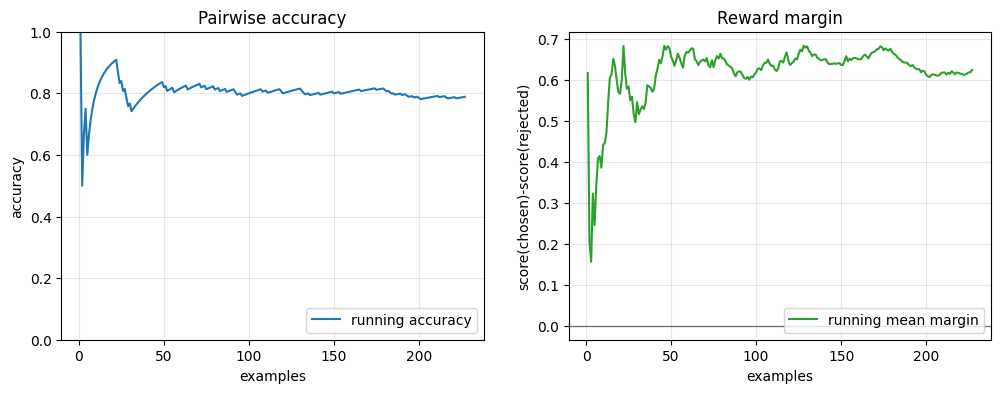


Final pairwise accuracy: 0.7885 (179/227)
Final mean margin: 0.6250


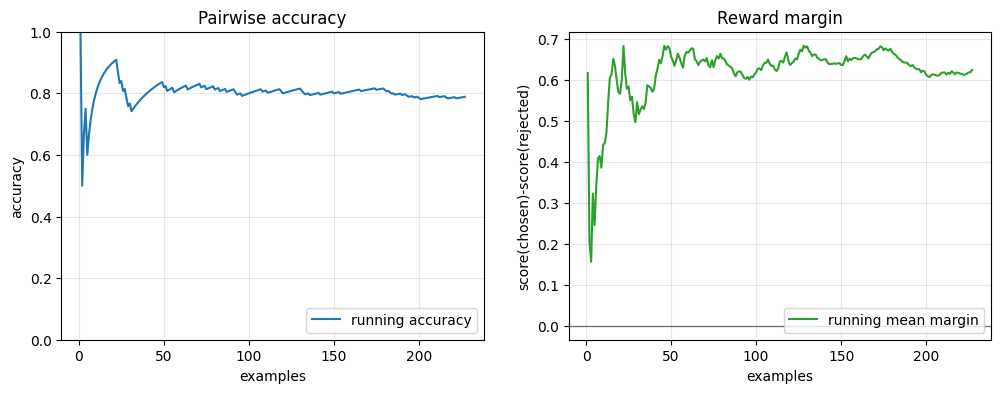

In [9]:
import sys
import subprocess
from importlib import metadata

import matplotlib.pyplot as plt
import torch
from IPython.display import clear_output, display
from peft import PeftModel
from tqdm.auto import tqdm
from transformers import AutoModelForSequenceClassification, AutoTokenizer

try:
    from packaging.version import Version as _Version
except Exception:  # pragma: no cover
    _Version = None


def _version_lt(a: str, b: str) -> bool:
    if _Version is not None:
        return _Version(a) < _Version(b)

    def _parse(v: str):
        out = []
        for p in v.split("."):
            try:
                out.append(int(p))
            except ValueError:
                break
        return out

    return _parse(a) < _parse(b)


def _ensure_compatible_peft_runtime(min_torchao: str = "0.16.0") -> None:
    """PEFT tries to use torchao when present; old torchao versions crash PEFT."""

    try:
        v = metadata.version("torchao")
    except metadata.PackageNotFoundError:
        return

    if _version_lt(v, min_torchao):
        print(
            f"torchao=={v} is incompatible with peft (need >={min_torchao}). "
            "Uninstalling torchao so peft falls back to the standard path..."
        )
        subprocess.check_call([sys.executable, "-m", "pip", "uninstall", "-y", "torchao"])


_ensure_compatible_peft_runtime()

tok = AutoTokenizer.from_pretrained(OUTPUT_DIR, trust_remote_code=True)

# Some models moved from torch_dtype -> dtype. Try the new arg first, fallback if needed.
try:
    base = AutoModelForSequenceClassification.from_pretrained(
        MODEL_ID,
        num_labels=1,
        trust_remote_code=True,
        dtype=_dtype,
        device_map="auto",
    )
except TypeError:
    base = AutoModelForSequenceClassification.from_pretrained(
        MODEL_ID,
        num_labels=1,
        trust_remote_code=True,
        torch_dtype=_dtype,
        device_map="auto",
    )

model = PeftModel.from_pretrained(base, OUTPUT_DIR)
model.eval()
_dev = next(model.parameters()).device


def score_one(prompt: str, answer: str) -> float:
    messages = [{"role": "user", "content": prompt}, {"role": "assistant", "content": answer}]
    text = tok.apply_chat_template(messages, tokenize=False)
    if tok.bos_token and text.startswith(tok.bos_token):
        text = text[len(tok.bos_token) :]
    enc = tok(text, return_tensors="pt", truncation=True, max_length=2048)
    enc = {k: v.to(_dev) for k, v in enc.items()}
    with torch.no_grad():
        return float(model(**enc).logits[0, 0].item())


# Тестовый датасет (если вдруг пустой, fallback на train)
val_ds = eval_ds if len(eval_ds) > 0 else train_ds
print(f"Validate on: {'eval_ds (test)' if len(eval_ds) > 0 else 'train_ds (fallback)'} | n={len(val_ds)}")

plot_every = max(1, len(val_ds) // 40)  # около 40 обновлений графика
correct = 0
xs, accs, margins = [], [], []

fig, (ax_acc, ax_margin) = plt.subplots(1, 2, figsize=(12, 4))

for i in tqdm(range(len(val_ds)), desc="Pairwise validation"):
    ex = val_ds[i]
    s_chosen = score_one(ex["prompt"], ex["chosen"])
    s_rejected = score_one(ex["prompt"], ex["rejected"])

    is_ok = int(s_chosen > s_rejected)
    correct += is_ok

    xs.append(i + 1)
    acc_now = correct / (i + 1)
    accs.append(acc_now)
    margins.append(s_chosen - s_rejected)

    if (i + 1) % plot_every == 0 or (i + 1) == len(val_ds):
        clear_output(wait=True)

        ax_acc.clear()
        ax_acc.plot(xs, accs, color="tab:blue", label="running accuracy")
        ax_acc.set_ylim(0.0, 1.0)
        ax_acc.set_xlabel("examples")
        ax_acc.set_ylabel("accuracy")
        ax_acc.set_title("Pairwise accuracy")
        ax_acc.grid(True, alpha=0.3)
        ax_acc.legend(loc="lower right")

        ax_margin.clear()
        running_margin = [sum(margins[:j]) / j for j in range(1, len(margins) + 1)]
        ax_margin.plot(xs, running_margin, color="tab:green", label="running mean margin")
        ax_margin.axhline(0.0, color="black", linewidth=1, alpha=0.5)
        ax_margin.set_xlabel("examples")
        ax_margin.set_ylabel("score(chosen)-score(rejected)")
        ax_margin.set_title("Reward margin")
        ax_margin.grid(True, alpha=0.3)
        ax_margin.legend(loc="lower right")

        display(fig)

final_acc = correct / len(val_ds)
mean_margin = sum(margins) / len(margins)
print(f"\nFinal pairwise accuracy: {final_acc:.4f} ({correct}/{len(val_ds)})")
print(f"Final mean margin: {mean_margin:.4f}")


In [10]:
# Метрики (accuracy / F1 / Cohen's kappa) для бинарной задачи
# "первый ответ лучше второго" с случайной перестановкой (баланс классов ~50/50).
# Это НЕ меняет датасет: мы только формируем задачу оценки поверх (prompt, chosen, rejected).

import random


def _metrics_binary(y_true, y_pred):
    n = len(y_true)
    assert n == len(y_pred) and n > 0

    tp = sum(1 for yt, yp in zip(y_true, y_pred) if yt == 1 and yp == 1)
    tn = sum(1 for yt, yp in zip(y_true, y_pred) if yt == 0 and yp == 0)
    fp = sum(1 for yt, yp in zip(y_true, y_pred) if yt == 0 and yp == 1)
    fn = sum(1 for yt, yp in zip(y_true, y_pred) if yt == 1 and yp == 0)

    acc = (tp + tn) / n
    prec = tp / (tp + fp) if (tp + fp) else 0.0
    rec = tp / (tp + fn) if (tp + fn) else 0.0
    f1 = (2 * prec * rec) / (prec + rec) if (prec + rec) else 0.0

    # Cohen's kappa
    p0 = acc
    p_true_pos = (tp + fn) / n
    p_true_neg = (tn + fp) / n
    p_pred_pos = (tp + fp) / n
    p_pred_neg = (tn + fn) / n
    pe = p_true_pos * p_pred_pos + p_true_neg * p_pred_neg
    kappa = (p0 - pe) / (1 - pe) if (1 - pe) else 0.0

    return {
        "accuracy": acc,
        "f1": f1,
        "cohen_kappa": kappa,
        "tp": tp,
        "tn": tn,
        "fp": fp,
        "fn": fn,
        "n": n,
    }


val_ds = eval_ds if len(eval_ds) > 0 else train_ds
print(f"Metrics split: {'eval_ds (test)' if len(eval_ds) > 0 else 'train_ds (fallback)'} | n={len(val_ds)}")

rng = random.Random(0)
y_true = []
y_pred = []

for i in tqdm(range(len(val_ds)), desc="Metrics (random swap)"):
    ex = val_ds[i]
    prompt = ex["prompt"]
    a = ex["chosen"]
    b = ex["rejected"]

    # y=1 means: first answer (a) is better than second (b)
    y = 1
    if rng.random() < 0.5:
        a, b = b, a
        y = 0

    sa = score_one(prompt, a)
    sb = score_one(prompt, b)
    pred = 1 if sa > sb else 0

    y_true.append(y)
    y_pred.append(pred)

m = _metrics_binary(y_true, y_pred)
print("\nMetrics (binary: 'first better than second')")
print(f"  accuracy    : {m['accuracy']:.4f}")
print(f"  f1          : {m['f1']:.4f}")
print(f"  cohen_kappa : {m['cohen_kappa']:.4f}")
print(f"  confusion   : tp={m['tp']} tn={m['tn']} fp={m['fp']} fn={m['fn']} (n={m['n']})")

Metrics split: eval_ds (test) | n=227


Metrics (random swap):   0%|          | 0/227 [00:00<?, ?it/s]


Metrics (binary: 'first better than second')
  accuracy    : 0.7885
  f1          : 0.7913
  cohen_kappa : 0.5782
  confusion   : tp=91 tn=88 fp=18 fn=30 (n=227)


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from tqdm.auto import tqdm

if "score_one" not in globals() or "tok" not in globals():
    raise RuntimeError("Сначала выполните ячейку с загрузкой модели и `score_one` (валидация / PeftModel).")

_ds_bias = eval_ds if len(eval_ds) > 0 else train_ds
MAX_ROWS = 250
rng = np.random.default_rng(SEED)
n = len(_ds_bias)
pick = rng.choice(n, size=min(MAX_ROWS, n), replace=False) if n > 0 else np.array([], dtype=int)


def _token_len_full(prompt: str, answer: str) -> int:
    messages = [{"role": "user", "content": prompt}, {"role": "assistant", "content": answer}]
    text = tok.apply_chat_template(messages, tokenize=False)
    if tok.bos_token and text.startswith(tok.bos_token):
        text = text[len(tok.bos_token) :]
    return len(tok.encode(text, add_special_tokens=False))


lens: list[int] = []
scs: list[float] = []
for i in tqdm(pick, desc="length vs score"):
    row = _ds_bias[int(i)]
    for key in ("chosen", "rejected"):
        lens.append(_token_len_full(row["prompt"], row[key]))
        scs.append(float(score_one(row["prompt"], row[key])))

L = np.asarray(lens, dtype=np.float64)
S = np.asarray(scs, dtype=np.float64)

if len(L) < 5:
    print("Слишком мало точек для графика.")
else:
    r_p = float(np.corrcoef(L, S)[0, 1])
    print("Pearson r (длина токенов vs score):", f"{r_p:.4f}")
    try:
        from scipy.stats import spearmanr

        print("Spearman rho:", f"{float(spearmanr(L, S).correlation):.4f}")
    except Exception as e:
        print("Spearman: недоступен (pip install scipy?)", e)

    edges = np.quantile(L, np.linspace(0, 1, 9))
    xs, ys = [], []
    for lo, hi in zip(edges[:-1], edges[1:]):
        m = (L >= lo) & (L <= hi)
        if np.sum(m) >= 3:
            xs.append(float(L[m].mean()))
            ys.append(float(S[m].mean()))

    plt.figure(figsize=(7, 5))
    plt.scatter(L, S, alpha=0.25, s=14, label="chosen + rejected")
    if xs:
        plt.plot(xs, ys, color="crimson", linewidth=2, marker="o", markersize=5, label="средний score по бинам")
    plt.xlabel("Длина входа reward (токены)")
    plt.ylabel("Score")
    plt.title("Длина ответа vs score (диагностика length bias)")
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()
